# Email Spam Detection

To run this project please install the following modules:

pip install numpy pandas matplotlib seaborn scikit-learn nltk jinja2

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import string
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve, average_precision_score
)

from nltk.corpus import stopwords

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
stop_words = set(stopwords.words('english'))

---
## 2. Text Preprocessing

Raw text cannot be fed directly into models. We apply three steps:

**Step 1 — Lowercase:** 'FREE' and 'free' should be the same token.

**Step 2 — Remove punctuation:** Characters like `!`, `$`, `.`.

**Step 3 — Remove stopwords:** Words like 'the', 'is', 'and' appear in almost every
message and carry no discriminative value for spam vs ham classification.

In [10]:
def preprocess(text):
    """Lowercase → remove punctuation → remove stopwords."""
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = [w for w in text.split()
              if w not in stop_words and 'escape' not in w and len(w) > 1]
    return ' '.join(tokens)

examples = [
    'CONGRATULATIONS! You have WON a FREE iPhone! CALL NOW: 07912345678',
    'Hey, are we still meeting for lunch today?'
]
for ex in examples:
    print(f'Before: {ex}')
    print(f'After:  {preprocess(ex)}\n')

Before: CONGRATULATIONS! You have WON a FREE iPhone! CALL NOW: 07912345678
After:  congratulations free iphone call 07912345678

Before: Hey, are we still meeting for lunch today?
After:  hey still meeting lunch today



---
## 3. Load Datasets
We reserve 2,500 emails for later testing

In [11]:
dataset1 = pd.read_csv('data/spam.csv', encoding='latin-1')
dataset1 = dataset1[['v1', 'v2']].rename(columns={'v1': 'label', 'v2': 'text'})
dataset1['source'] = 'Assignment Dataset'
print(f'Assignment provided dataset:   {len(dataset1):,} rows  |  spam rate: {(dataset1["label"]=="spam").mean():.1%}')

dataset2 = pd.read_csv('data/spam_Emails_data.csv', engine='python', on_bad_lines='skip')
dataset2 = dataset2[dataset2['label'].isin(['Spam','Ham'])].reset_index(drop=True)
HOLDOUT_SIZE = 2500
training_pool_email = dataset2.iloc[:-HOLDOUT_SIZE].copy()
holdout_pool        = dataset2.iloc[-HOLDOUT_SIZE:].copy()
print(f'External email training pool: {len(training_pool_email):,}  |  Held-out: {len(holdout_pool):,}')
training_pool_email['label']  = training_pool_email['label'].map({'Spam':'spam','Ham':'ham'})
training_pool_email['source'] = 'Email'

dataset3 = pd.read_csv('data/spam_Emails_data_1.csv', encoding='latin-1', engine='python', on_bad_lines='skip')
dataset3 = dataset3[dataset3['label'].isin(['Spam','Ham'])].reset_index(drop=True)
dataset3['label']  = dataset3['label'].map({'Spam':'spam','Ham':'ham'})
dataset3['source'] = 'Email Dataset 2'
print(f'Email dataset 2: {len(dataset3):,} rows  |  spam rate: {(dataset3["label"]=="spam").mean():.1%}')

combined = pd.concat([
    dataset1[['text','label','source']],
    training_pool_email[['text','label','source']],
    dataset3[['text','label','source']]
], ignore_index=True)
combined = combined.dropna(subset=['text','label'])
combined['length'] = combined['text'].apply(lambda x: len(str(x)))

print(f'\nCombined: {len(combined):,} rows | spam: {(combined["label"]=="spam").mean():.1%}')
combined.head()

Assignment provided dataset:   5,572 rows  |  spam rate: 13.4%
External email training pool: 4,413  |  Held-out: 2,500
Email dataset 2: 10,414 rows  |  spam rate: 47.0%

Combined: 20,399 rows | spam: 37.8%


,text,label,source,length
0,"Go until jurong point, crazy.. Available only ...",ham,Assignment Dataset,111
1,Ok lar... Joking wif u oni...,ham,Assignment Dataset,29
2,Free entry in 2 a wkly comp to win FA Cup fina...,spam,Assignment Dataset,155
3,U dun say so early hor... U c already then say...,ham,Assignment Dataset,49
4,"Nah I don't think he goes to usf, he lives aro...",ham,Assignment Dataset,61


### Figure 1: Combined Dataset Overview

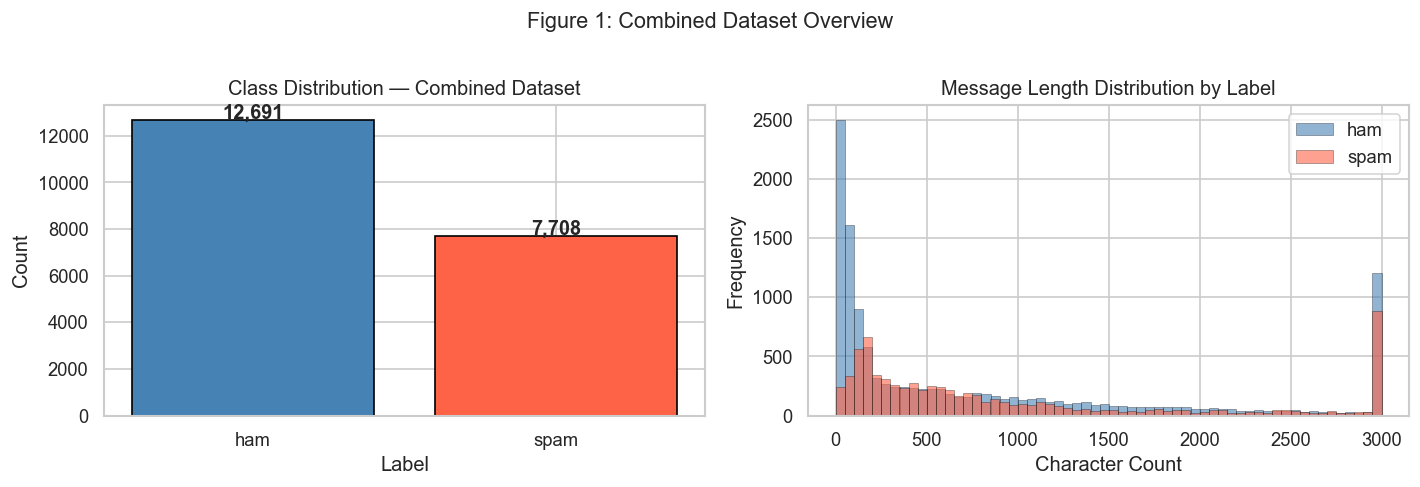

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = combined['label'].value_counts()
axes[0].bar(counts.index, counts.values, color=['steelblue','tomato'], edgecolor='black')
axes[0].set_title('Class Distribution — Combined Dataset')
axes[0].set_xlabel('Label'); axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

for label, color in [('ham','steelblue'),('spam','tomato')]:
    subset = combined[combined['label']==label]['length'].clip(upper=3000)
    axes[1].hist(subset, bins=60, alpha=0.6, color=color, label=label, edgecolor='black', linewidth=0.3)
axes[1].set_title('Message Length Distribution by Label')
axes[1].set_xlabel('Character Count'); axes[1].set_ylabel('Frequency')
axes[1].legend()
plt.suptitle('Figure 1: Combined Dataset Overview', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('graphs/fig1_combined_distribution.png', bbox_inches='tight')
plt.show()

---
## 4. Preprocess

In [13]:
combined['clean'] = combined['text'].apply(preprocess)

X_train, X_test, y_train, y_test = train_test_split(
    combined['clean'], combined['label'],
    test_size=0.30, random_state=42, stratify=combined['label']
)
print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}')
print(f'Train spam rate: {(y_train=="spam").mean():.1%}  |  Test spam rate: {(y_test=="spam").mean():.1%}')

Train: 14,279  |  Test: 6,120
Train spam rate: 37.8%  |  Test spam rate: 37.8%


---
## 5. Model Training

---

### 5.1 Solution: Naive Bayes (MultinomialNB, α = 0.1)

#### 5.1.1 Method Description

Naive Bayes applies Bayes' theorem with the *naive* assumption that features
(word frequencies) are conditionally independent given the class:

$$P(\text{spam} \mid \mathbf{x}) = \frac{P(\mathbf{x} \mid \text{spam})\, P(\text{spam})}{P(\mathbf{x})}$$

For the Multinomial variant each word $w_i$ contributes a frequency count $x_i$:

$$P(\mathbf{x} \mid c) = \prod_{i} P(w_i \mid c)^{x_i}$$

Laplace smoothing (α = 0.1) prevents zero probabilities for words not seen in
training:
`
$$\hat{P}(w_i \mid c) = \frac{\text{count}(w_i, c) + \alpha}{\sum_j \text{count}(w_j, c) + \alpha |V|}$$

**Why α = 0.1?**  The default α = 1.0 over-smooths on large vocabularies.
A smaller α preserves more of the frequency signal.

*Strengths:* very fast; effective on sparse high-dimensional text; naturally
high precision.  *Weakness:* the independence assumption rarely holds; it
tends to miss subtler spam patterns, resulting in lower recall.

---

### 5.2 Solution: SVM — LinearSVC + CalibratedClassifierCV (C = 1.0)

#### 5.2.1 Method Description

A Support Vector Machine finds the **maximum-margin hyperplane** separating
ham from spam.  For linearly separable data the boundary is:

$$\mathbf{w}^\top \mathbf{x} + b = 0$$

Training minimises hinge loss with L2 regularisation:

$$\min_{\mathbf{w}} \frac{1}{2}\|\mathbf{w}\|^2 + C \sum_i \max(0,\, 1 - y_i(\mathbf{w}^\top \mathbf{x}_i + b))$$

$C = 1.0$ balances margin width vs. training error.  Larger $C$ → narrower
margin, more training accuracy but risk of overfitting.

`CalibratedClassifierCV` wraps LinearSVC with **Platt scaling** (3-fold CV)
to turn raw decision scores into proper probabilities, required for ROC / PR
curves.

*Strengths:* high recall; handles high-dimensional sparse features efficiently.
*Weakness:* slower to train than NB; calibrated probabilities are approximate.

---

### 5.3 Solution: Logistic Regression (C = 1.0, solver = 'lbfgs')

#### 5.3.1 Method Description

Logistic Regression models the log-odds of the spam class as a linear function
of the TF-IDF features, then applies the sigmoid activation:

$$P(\text{spam} \mid \mathbf{x}) = \sigma(\mathbf{w}^\top \mathbf{x} + b) = \frac{1}{1 + e^{-(\mathbf{w}^\top \mathbf{x} + b)}}$$

Training maximises the regularised log-likelihood:

$$\mathcal{L} = \sum_i \left[ y_i \log \hat{p}_i + (1-y_i)\log(1-\hat{p}_i) \right] - \frac{1}{2C}\|\mathbf{w}\|^2$$

The $1/C$ term penalises large weights; $C = 1.0$ is a balanced default.

*Strengths:* well-calibrated probabilities; coefficients are directly
interpretable as feature importance; competitive on both precision and recall.
*Weakness:* assumes a log-linear decision boundary.

In [14]:
nb_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1,2), max_df=0.9)),
    ('clf',   MultinomialNB(alpha=0.1))
])
nb_pipe.fit(X_train, y_train)
print('Naive Bayes trained.')

svm_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1,2), max_df=0.9)),
    ('clf',   CalibratedClassifierCV(LinearSVC(C=1.0, max_iter=2000, random_state=42), cv=3))
])
svm_pipe.fit(X_train, y_train)
print('SVM trained.')

lr_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1,2), max_df=0.9)),
    ('clf',   LogisticRegression(C=10.0, penalty='l2', solver='liblinear', max_iter=1000, random_state=42))
])
lr_pipe.fit(X_train, y_train)
print('Logistic Regression trained.')

models      = {'Naive Bayes': nb_pipe, 'SVM': svm_pipe, 'Logistic Regression': lr_pipe}
model_names = list(models.keys())
colors3     = ['steelblue', 'seagreen', 'darkorange']
markers3    = ['o', 's', 'D']
print('All 3 models trained.')

Naive Bayes trained.
SVM trained.
Logistic Regression trained.
All 3 models trained.


---
## 6. Evaluation Metrics

| Metric | Formula | When it matters |
|--------|---------|-----------------|
| **Accuracy** | (TP+TN)/Total | Baseline, misleading when imbalanced |
| **Precision** | TP/(TP+FP) | When false positives are costly (blocking legit email) |
| **Recall** | TP/(TP+FN) | When false negatives are costly (missing phishing) |
| **F1 (macro)** | Mean F1 per class | Primary metric — balances across both classes equally |

Green highlight = best model for metric.

In [15]:
def evaluate_models(models, X_te, y_te):
    results = []
    for name, model in models.items():
        y_pred = model.predict(X_te)
        results.append({
            'Model':      name,
            'Accuracy':   accuracy_score(y_te, y_pred),
            'Precision':  precision_score(y_te, y_pred, pos_label='spam'),
            'Recall':     recall_score(y_te, y_pred, pos_label='spam'),
            'F1 (macro)': f1_score(y_te, y_pred, average='macro')
        })
    df = pd.DataFrame(results).set_index('Model')
    display(df.style.highlight_max(axis=0, color='darkgreen').format('{:.4f}'))
    return df

results_df = evaluate_models(models, X_test, y_test)

,Accuracy,Precision,Recall,F1 (macro)
Model,,,,
Naive Bayes,0.9422,0.9653,0.8785,0.9373
SVM,0.9451,0.9270,0.9278,0.9416
Logistic Regression,0.9443,0.9486,0.9014,0.9401


---
## 7. Visualisations — Figures 3–8

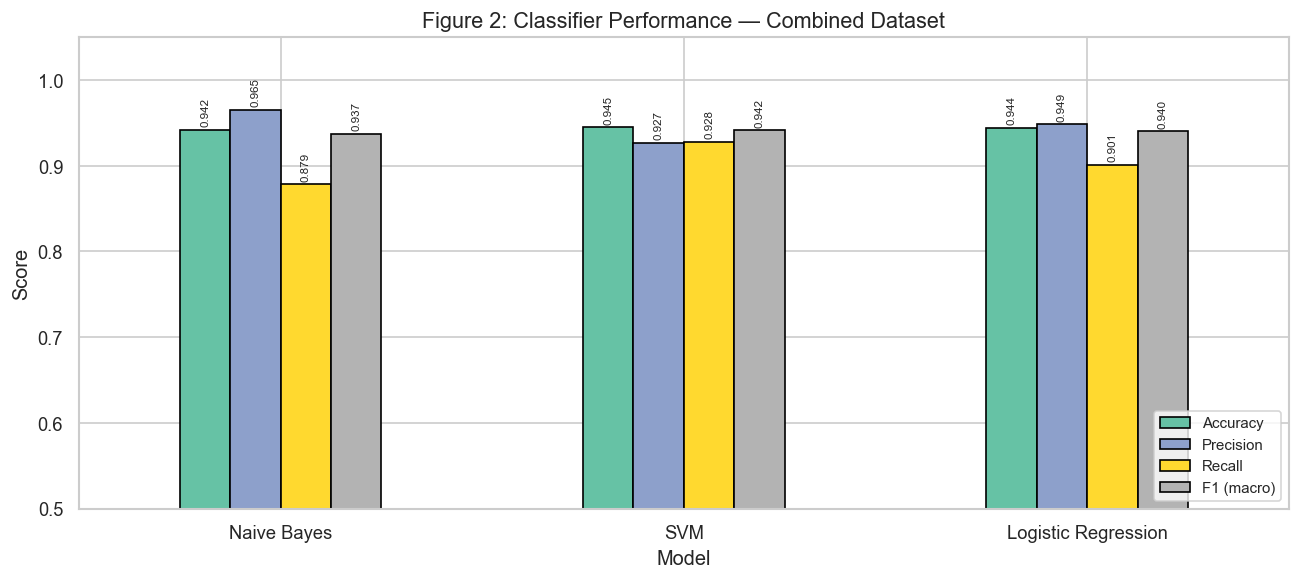

In [16]:
fig, ax = plt.subplots(figsize=(11, 5))
results_df.plot(kind='bar', ax=ax, edgecolor='black', colormap='Set2', rot=0)
ax.set_ylim(0.50, 1.05)
ax.set_title('Figure 2: Classifier Performance — Combined Dataset', fontsize=13)
ax.set_ylabel('Score'); ax.set_xlabel('Model')
ax.legend(loc='lower right', fontsize=9)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=7, padding=2, rotation=90)
plt.tight_layout()
plt.savefig('graphs/fig2_metrics_comparison.png', bbox_inches='tight')
plt.show()

### Figure 4: Confusion Matrices
- **Top-left (TN):** Ham correctly classified — legitimate mail left alone.
- **Bottom-right (TP):** Spam correctly caught.
- **Top-right (FP):** Ham flagged as spam — *false positive* — **user loses legitimate email**.
- **Bottom-left (FN):** Spam missed — *false negative* — **spam slips through**.

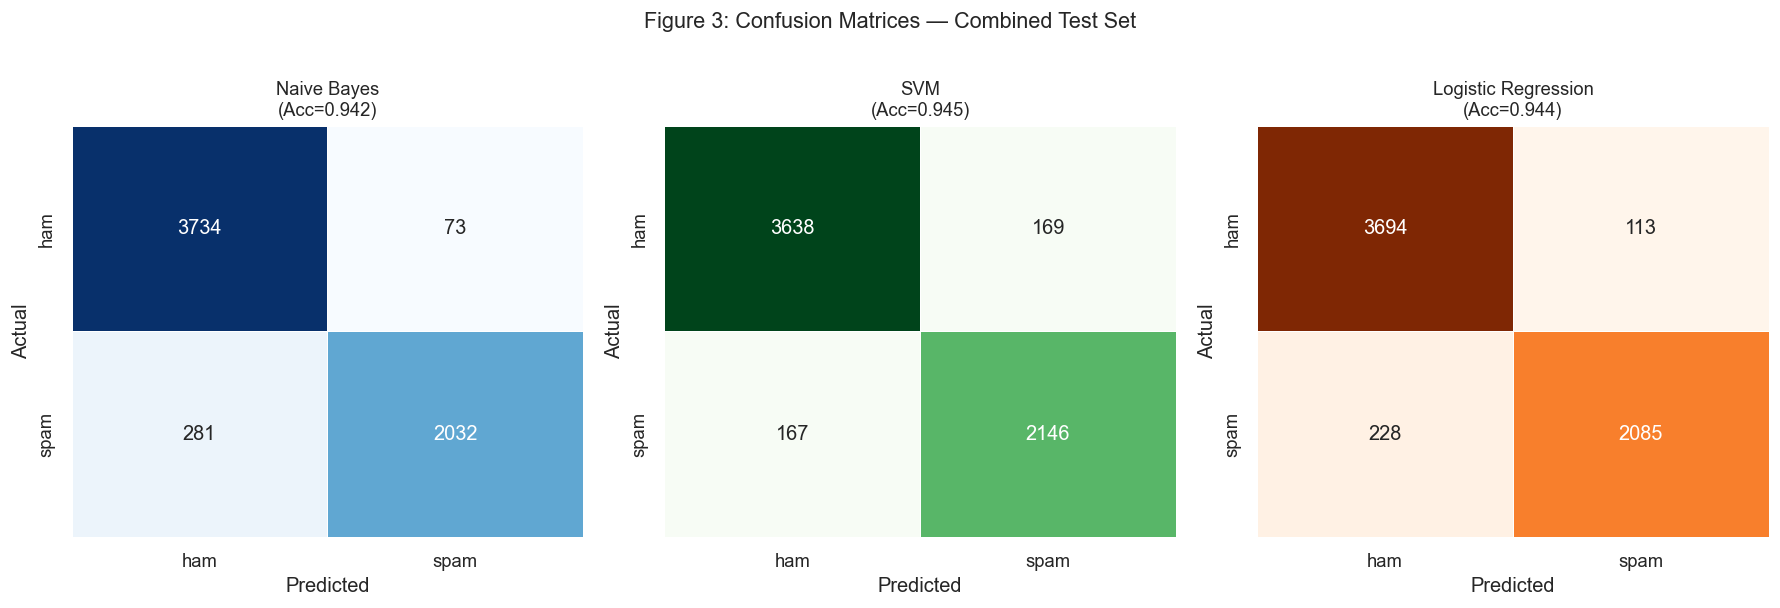

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (name, model), cmap in zip(axes, models.items(), ['Blues','Greens','Oranges']):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred, labels=['ham','spam'])
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['ham','spam'], yticklabels=['ham','spam'],
                linewidths=0.5, cbar=False)
    ax.set_title(f'{name}\n(Acc={accuracy_score(y_test, model.predict(X_test)):.3f})', fontsize=11)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.suptitle('Figure 3: Confusion Matrices — Combined Test Set', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('graphs/fig3_confusion_matrices.png', bbox_inches='tight')
plt.show()

### Figure 4: ROC Curves

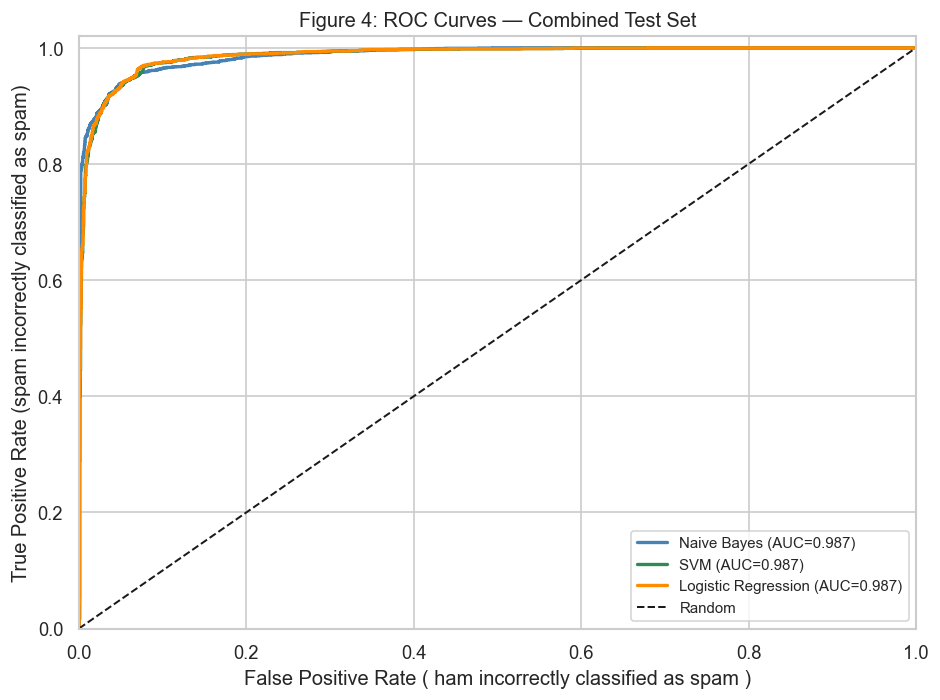

In [18]:
fig, ax = plt.subplots(figsize=(8, 6))
y_bin = (y_test == 'spam').astype(int)
for (name, model), color in zip(models.items(), colors3):
    y_prob   = model.predict_proba(X_test)
    spam_idx = list(model.classes_).index('spam')
    fpr, tpr, _ = roc_curve(y_bin, y_prob[:, spam_idx])
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc(fpr,tpr):.3f})')
ax.plot([0,1],[0,1],'k--', lw=1.2, label='Random')
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
ax.set_xlabel('False Positive Rate ( ham incorrectly classified as spam )' ); ax.set_ylabel('True Positive Rate (spam incorrectly classified as spam)')
ax.set_title('Figure 4: ROC Curves — Combined Test Set', fontsize=12)
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('graphs/fig_roc_curves.png', bbox_inches='tight')
plt.show()

### Figure 5: Precision-Recall Curves

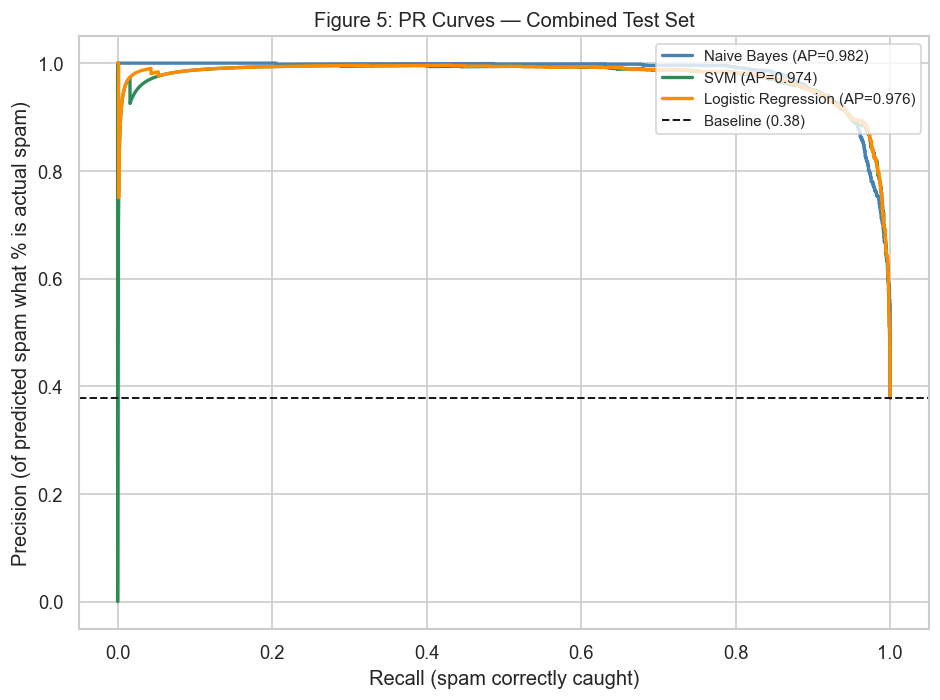

In [19]:
fig, ax = plt.subplots(figsize=(8, 6))
for (name, model), color in zip(models.items(), colors3):
    y_prob   = model.predict_proba(X_test)
    spam_idx = list(model.classes_).index('spam')
    prec, rec, _ = precision_recall_curve(y_bin, y_prob[:, spam_idx])
    ap = average_precision_score(y_bin, y_prob[:, spam_idx])
    ax.plot(rec, prec, color=color, lw=2, label=f'{name} (AP={ap:.3f})')
ax.axhline(y=y_bin.mean(), color='k', linestyle='--', lw=1.2, label=f'Baseline ({y_bin.mean():.2f})')
ax.set_xlabel('Recall (spam correctly caught)'); 
ax.set_ylabel('Precision (of predicted spam what % is actual spam)')
ax.set_title('Figure 5: PR Curves — Combined Test Set', fontsize=12)
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig('graphs/fig5_pr_curves.png', bbox_inches='tight')
plt.show()

### Figure 6: Top Features — Naive Bayes

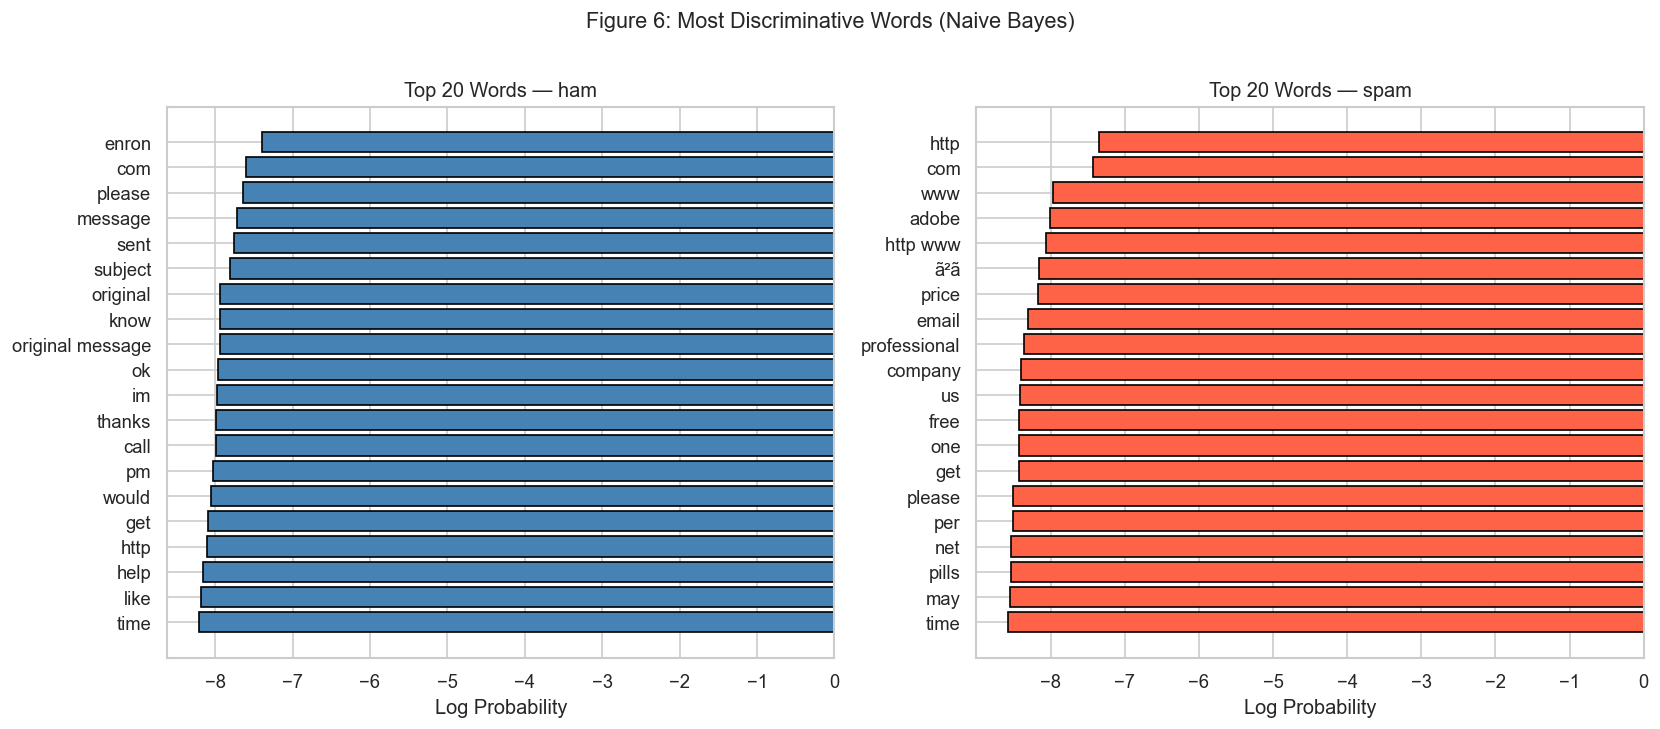

In [20]:
nb_tfidf  = nb_pipe.named_steps['tfidf']
nb_clf    = nb_pipe.named_steps['clf']
feat_names = np.array(nb_tfidf.get_feature_names_out())
log_probs  = nb_clf.feature_log_prob_
nb_classes = nb_clf.classes_

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (label, color) in zip(axes, [('ham','steelblue'),('spam','tomato')]):
    ci = list(nb_classes).index(label)
    top_idx = log_probs[ci].argsort()[-20:][::-1]
    ax.barh(feat_names[top_idx][::-1], log_probs[ci][top_idx][::-1], color=color, edgecolor='black')
    ax.set_title(f'Top 20 Words — {label}', fontsize=12)
    ax.set_xlabel('Log Probability')
plt.suptitle('Figure 6: Most Discriminative Words (Naive Bayes)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('graphs/fig6_nb_top_words.png', bbox_inches='tight')
plt.show()

### Figure 7: Top Features — Logistic Regression

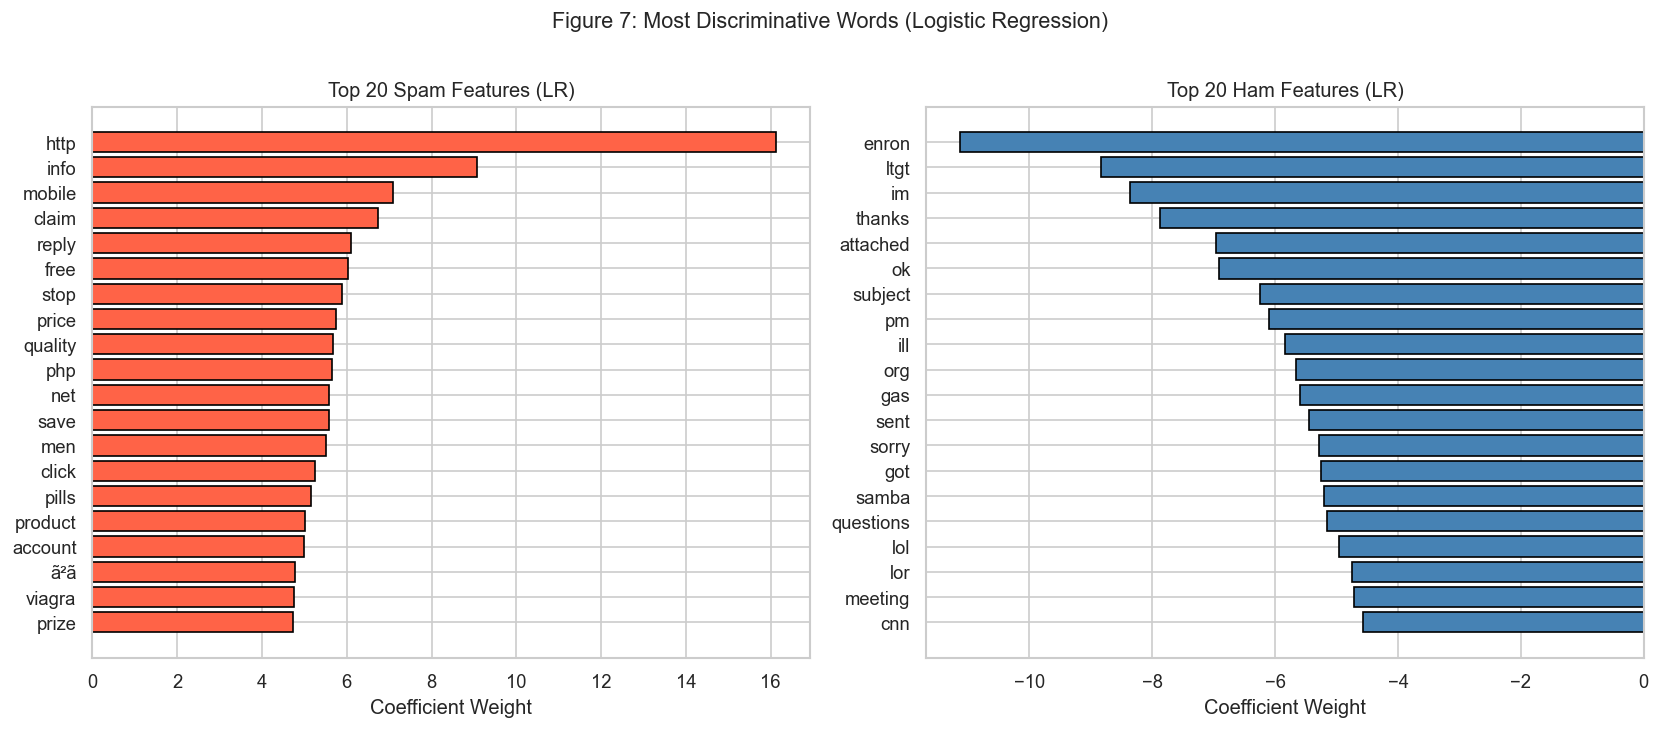

In [21]:
lr_tfidf = lr_pipe.named_steps['tfidf']
lr_clf   = lr_pipe.named_steps['clf']
lr_feat  = np.array(lr_tfidf.get_feature_names_out())
lr_coef  = lr_clf.coef_[0]

spam_idx_lr = lr_coef.argsort()[-20:][::-1]
ham_idx_lr  = lr_coef.argsort()[:20]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].barh(lr_feat[spam_idx_lr][::-1], lr_coef[spam_idx_lr][::-1], color='tomato', edgecolor='black')
axes[0].set_title('Top 20 Spam Features (LR)', fontsize=12)
axes[0].set_xlabel('Coefficient Weight')
axes[1].barh(lr_feat[ham_idx_lr][::-1], lr_coef[ham_idx_lr][::-1], color='steelblue', edgecolor='black')
axes[1].set_title('Top 20 Ham Features (LR)', fontsize=12)
axes[1].set_xlabel('Coefficient Weight')
plt.suptitle('Figure 7: Most Discriminative Words (Logistic Regression)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('graphs/fig7_lr_top_words.png', bbox_inches='tight')
plt.show()

---
## 8. Reports

### 8.1 Detailed Classification

In [22]:
for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f'\n{"="*50}')
    print(f'{name}')
    print(f'{"="*50}')
    print(classification_report(y_test, y_pred, target_names=['ham','spam']))


Naive Bayes
              precision    recall  f1-score   support

         ham       0.93      0.98      0.95      3807
        spam       0.97      0.88      0.92      2313

    accuracy                           0.94      6120
   macro avg       0.95      0.93      0.94      6120
weighted avg       0.94      0.94      0.94      6120


SVM
              precision    recall  f1-score   support

         ham       0.96      0.96      0.96      3807
        spam       0.93      0.93      0.93      2313

    accuracy                           0.95      6120
   macro avg       0.94      0.94      0.94      6120
weighted avg       0.95      0.95      0.95      6120


Logistic Regression
              precision    recall  f1-score   support

         ham       0.94      0.97      0.96      3807
        spam       0.95      0.90      0.92      2313

    accuracy                           0.94      6120
   macro avg       0.95      0.94      0.94      6120
weighted avg       0.94      0.94  

### 8.2 Prediction Examples

In [23]:
# ── 2.x Prediction Examples ─────────────────────────────────────────────────
# Hand-crafted + real example messages (not from training data)
example_messages = [
    ("Obvious spam",     "WINNER!! You have been selected to receive a £1000 cash prize. Call NOW!"),
    ("Subtle spam",      "Free entry: txt WIN to 87121 to receive your guaranteed gift."),
    ("Borderline",       "Hi, just calling to let you know your account needs attention. Please call us."),
    ("Clear ham",        "Are you coming to the meeting at 3pm today? Let me know if you need the link."),
    ("Casual ham",       "haha yeah i'll be there, see you tonight"),
    ("Phishing attempt", "Your bank account has been suspended. Verify immediately at http://secure-login.net"),
    ("Newsletter",       "Unsubscribe from our mailing list by clicking the link below."),
]

print(f"{'Message type':<22} {'Label':<12} {'NB conf':>9} {'SVM conf':>9} {'LR conf':>9}")
print("-" * 65)

for msg_type, raw_msg in example_messages:
    cleaned = preprocess(raw_msg)
    row = [msg_type]
    confs = []
    label = None
    for name, model in models.items():
        pred  = model.predict([cleaned])[0]
        prob  = model.predict_proba([cleaned])[0]
        sidx  = list(model.classes_).index('spam')
        spam_prob = prob[sidx]
        confs.append(f"{spam_prob:.3f}")
        if label is None:
            label = pred
    print(f"{msg_type:<22} {label:<12} {confs[0]:>9} {confs[1]:>9} {confs[2]:>9}")

print()

Message type           Label          NB conf  SVM conf   LR conf
-----------------------------------------------------------------
Obvious spam           spam             0.999     1.000     0.975
Subtle spam            spam             0.984     1.000     0.993
Borderline             ham              0.087     0.356     0.250
Clear ham              ham              0.023     0.001     0.009
Casual ham             ham              0.001     0.000     0.005
Phishing attempt       spam             0.742     0.997     0.919
Newsletter             spam             0.655     0.138     0.173



---
## 9. Deep Model Comparison

### Figure 8: Per-Model Metrics — All Four Side-by-Side

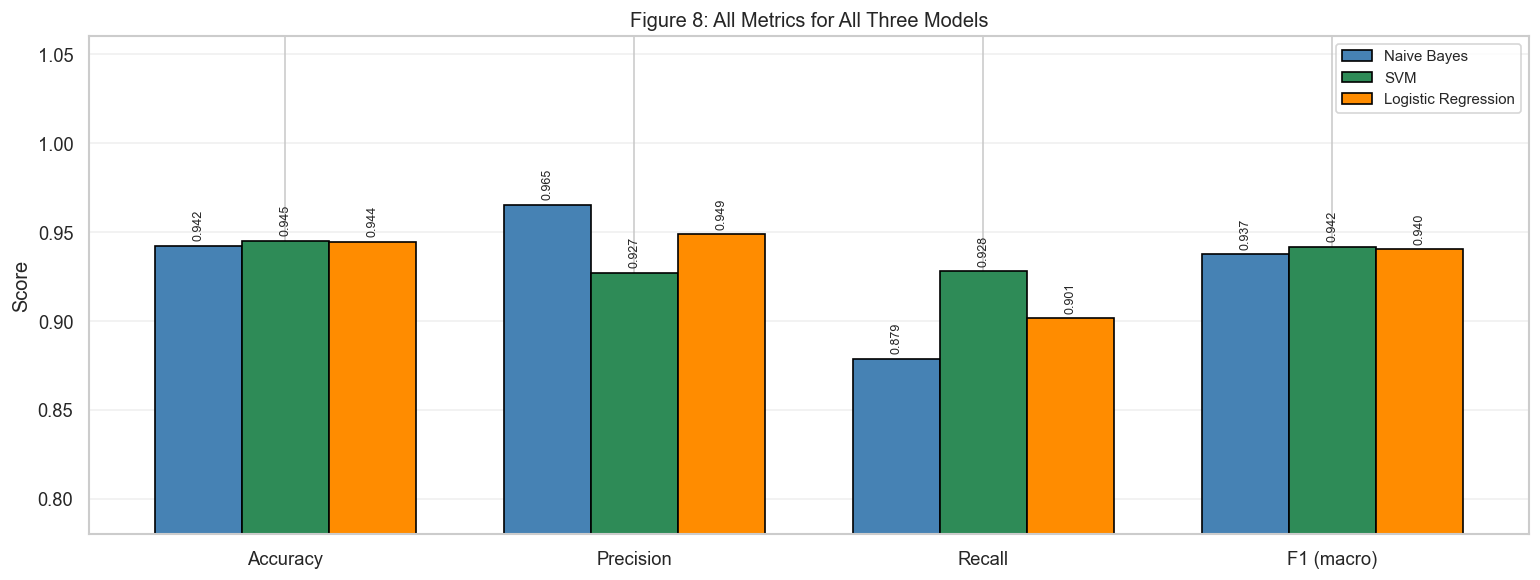

In [24]:
metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1 (macro)']

fig, ax = plt.subplots(figsize=(13, 5))
x     = np.arange(len(metrics_list))
width = 0.25
for i, (mname, color) in enumerate(zip(model_names, colors3)):
    vals = [results_df.loc[mname, m] for m in metrics_list]
    bars = ax.bar(x + (i-1)*width, vals, width, label=mname, color=color, edgecolor='black')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7.5, rotation=90)
ax.set_xticks(x); ax.set_xticklabels(metrics_list)
ax.set_ylim(0.78, 1.06); ax.set_ylabel('Score')
ax.set_title('Figure 8: All Metrics for All Three Models', fontsize=12)
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('graphs/fig8_per_model_metrics.png', bbox_inches='tight')
plt.show()

### Figure 10: Metric Disagreement — Gap from Best-in-Class

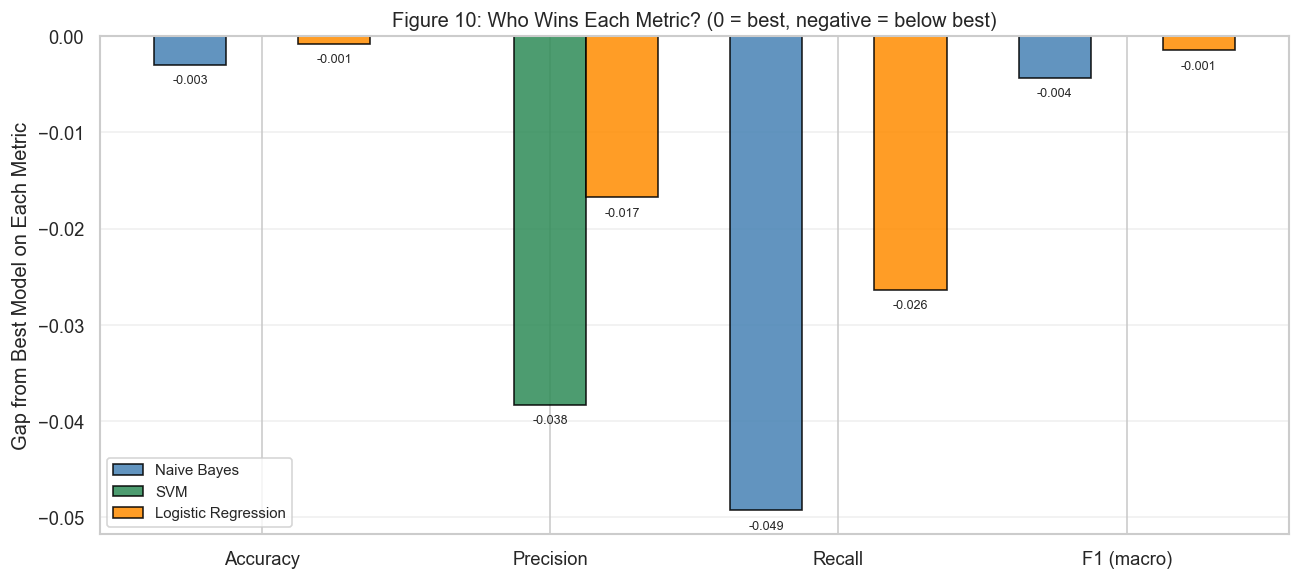

In [25]:
best_vals = results_df[metrics_list].max(axis=0)
gap_df    = results_df[metrics_list].subtract(best_vals, axis=1)

fig, ax = plt.subplots(figsize=(11, 5))
x     = np.arange(len(metrics_list))
width = 0.25
for i, (mname, color) in enumerate(zip(model_names, colors3)):
    gaps = [gap_df.loc[mname, m] for m in metrics_list]
    bars = ax.bar(x + (i-1)*width, gaps, width, label=mname, color=color, edgecolor='black', alpha=0.85)
    for bar, g in zip(bars, gaps):
        if abs(g) > 0.0005:
            ax.text(bar.get_x()+bar.get_width()/2, g - 0.001, f'{g:.3f}', ha='center', va='top', fontsize=7.5)
ax.axhline(0, color='black', lw=1.2)
ax.set_xticks(x); ax.set_xticklabels(metrics_list)
ax.set_ylabel('Gap from Best Model on Each Metric')
ax.set_title('Figure 10: Who Wins Each Metric? (0 = best, negative = below best)', fontsize=12)
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('graphs/fig10_metric_disagreement.png', bbox_inches='tight')
plt.show()

### Figure 11: Radar Chart

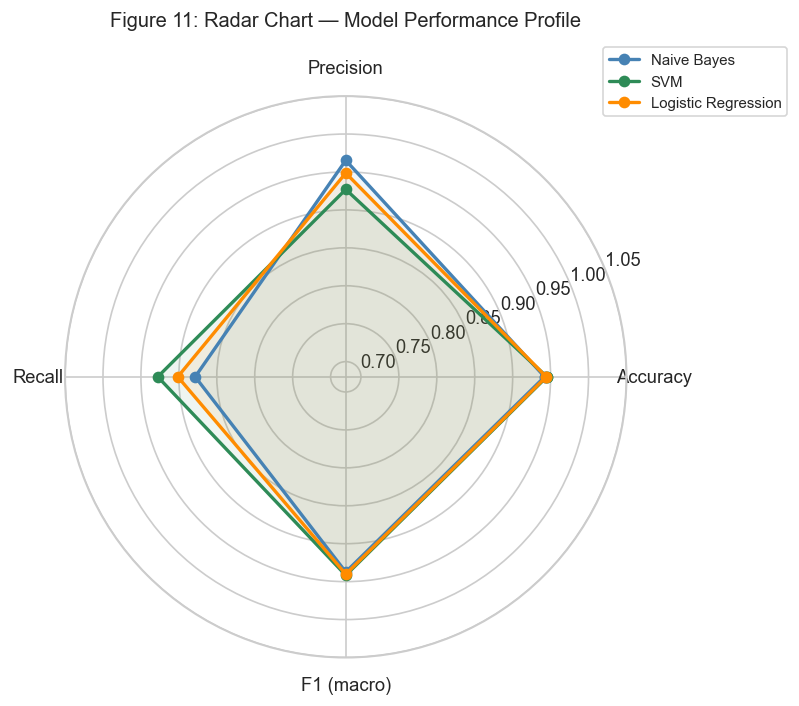

In [26]:
metrics_radar = ['Accuracy', 'Precision', 'Recall', 'F1 (macro)']
N      = len(metrics_radar)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
for mname, color in zip(model_names, colors3):
    values  = [results_df.loc[mname, m] for m in metrics_radar]
    values += values[:1]
    ax.plot(angles, values, 'o-', lw=2, color=color, label=mname)
    ax.fill(angles, values, alpha=0.08, color=color)
ax.set_xticks(angles[:-1]); ax.set_xticklabels(metrics_radar, fontsize=11)
ax.set_ylim(0.68, 1.05)
ax.set_title('Figure 11: Radar Chart — Model Performance Profile', fontsize=12, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=9)
plt.tight_layout()
plt.savefig('graphs/fig11_radar.png', bbox_inches='tight')
plt.show()

### Figure 12: Parallel Coordinates

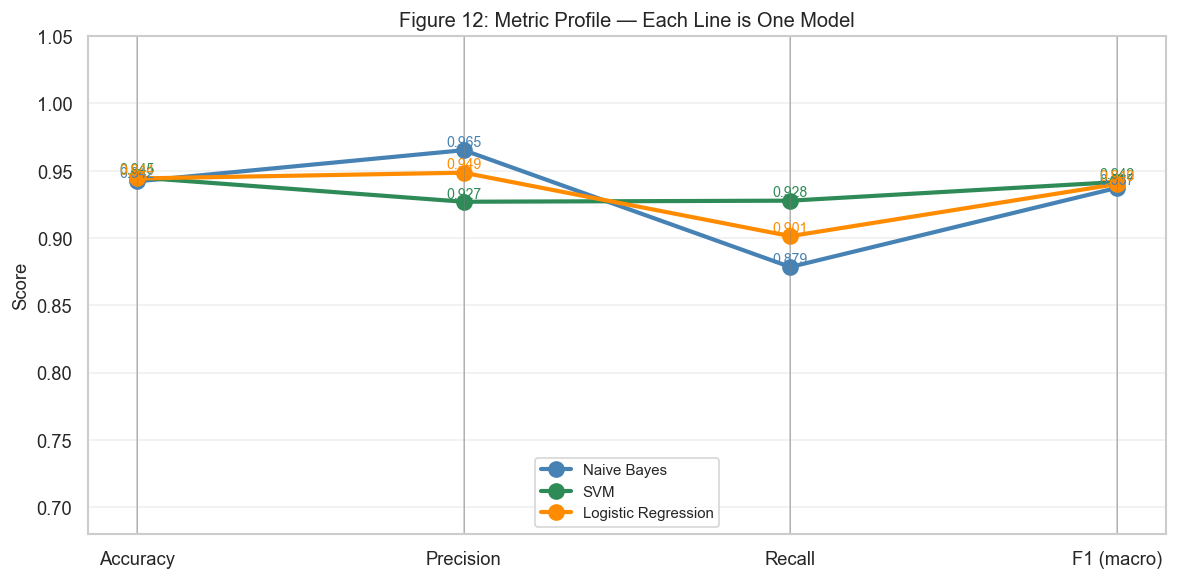

In [27]:
fig, ax = plt.subplots(figsize=(10, 5))
metrics_pc = ['Accuracy', 'Precision', 'Recall', 'F1 (macro)']
x_pos = np.arange(len(metrics_pc))

for mname, color in zip(model_names, colors3):
    vals = [results_df.loc[mname, m] for m in metrics_pc]
    ax.plot(x_pos, vals, 'o-', color=color, lw=2.5, markersize=9, label=mname)
    for xi, v in zip(x_pos, vals):
        ax.text(xi, v + 0.003, f'{v:.3f}', ha='center', fontsize=8.5, color=color)

ax.set_xticks(x_pos); ax.set_xticklabels(metrics_pc, fontsize=11)
ax.set_ylim(0.68, 1.05); ax.set_ylabel('Score', fontsize=11)
ax.set_title('Figure 12: Metric Profile — Each Line is One Model', fontsize=12)
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
for xi in x_pos:
    ax.axvline(xi, color='grey', lw=0.5, alpha=0.5)
plt.tight_layout()
plt.savefig('graphs/fig12_parallel_coords.png', bbox_inches='tight')
plt.show()

### Figure 13: Error Analysis — False Positives vs False Negatives
 **False Positive Rate (FPR):** Fraction of legitimate (ham) messages wrongly
  flagged as spam. High FPR = users lose legitimate emails.

**False Negative Rate (FNR):** Fraction of actual spam that slips through.
  High FNR = more phishing / malware reaches the inbox.


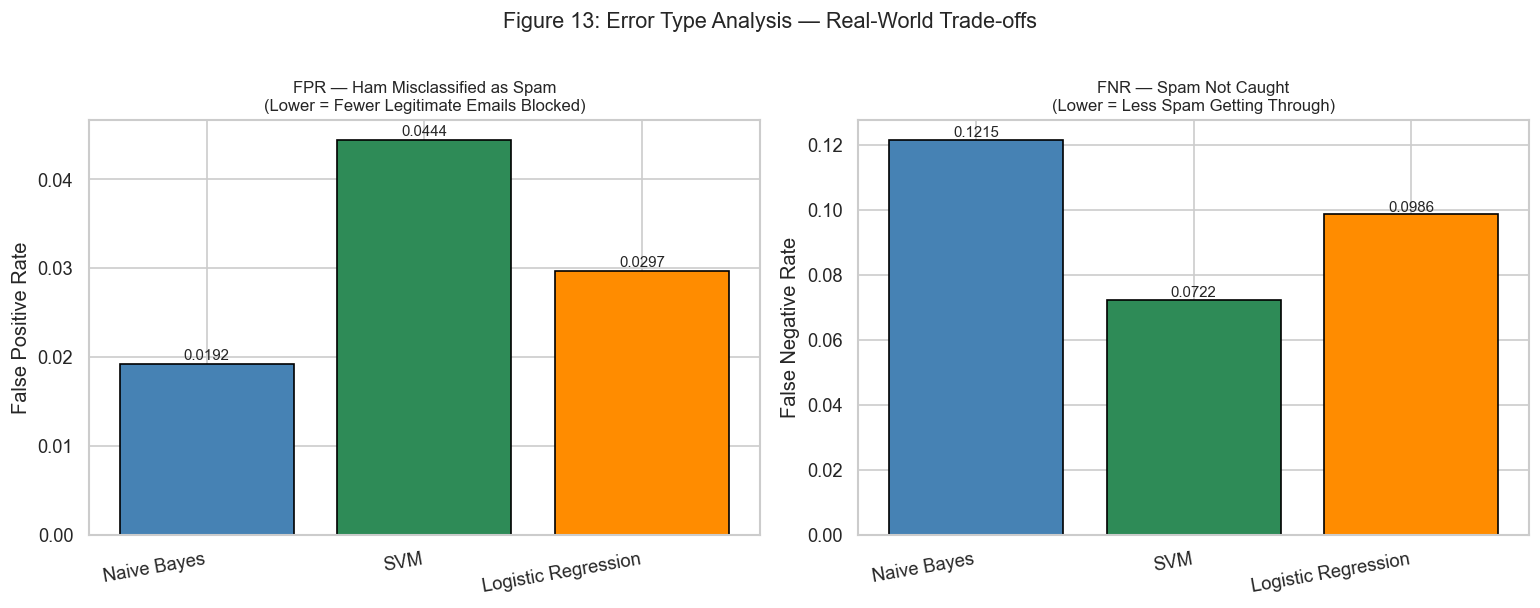

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

fp_rates, fn_rates = [], []
for mname, model in models.items():
    y_pred = model.predict(X_test)
    cm_arr = confusion_matrix(y_test, y_pred, labels=['ham','spam'])
    tn, fp, fn, tp = cm_arr.ravel()
    fp_rates.append(fp / (fp + tn) if (fp + tn) > 0 else 0)
    fn_rates.append(fn / (fn + tp) if (fn + tp) > 0 else 0)

x = np.arange(len(model_names))
axes[0].bar(x, fp_rates, color=colors3, edgecolor='black')
axes[0].set_xticks(x); axes[0].set_xticklabels(model_names, rotation=10, ha='right')
axes[0].set_ylabel('False Positive Rate')
axes[0].set_title('FPR — Ham Misclassified as Spam\n(Lower = Fewer Legitimate Emails Blocked)', fontsize=10)
for i, v in enumerate(fp_rates):
    axes[0].text(i, v + 0.0005, f'{v:.4f}', ha='center', fontsize=9)

axes[1].bar(x, fn_rates, color=colors3, edgecolor='black')
axes[1].set_xticks(x); axes[1].set_xticklabels(model_names, rotation=10, ha='right')
axes[1].set_ylabel('False Negative Rate')
axes[1].set_title('FNR — Spam Not Caught\n(Lower = Less Spam Getting Through)', fontsize=10)
for i, v in enumerate(fn_rates):
    axes[1].text(i, v + 0.001, f'{v:.4f}', ha='center', fontsize=9)

plt.suptitle('Figure 13: Error Type Analysis — Real-World Trade-offs', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('graphs/fig13_error_analysis.png', bbox_inches='tight')
plt.show()

---
## 10. Real-World Validation: 2,500 Unseen Messages

Models run on 2,500 dataset saved from earlier

In [29]:
# Prepare held-out set
holdout_pool['label_std'] = holdout_pool['label'].map({'Spam': 'spam', 'Ham': 'ham'})
holdout_pool['clean']     = holdout_pool['text'].apply(preprocess)
X_holdout      = holdout_pool['clean']
y_holdout_true = holdout_pool['label_std']

print(f'Held-out messages: {len(X_holdout):,}')
print(f'True distribution: {y_holdout_true.value_counts().to_dict()}')
print(f'Spam rate:         {(y_holdout_true == "spam").mean():.1%}')

Held-out messages: 2,500
True distribution: {'ham': 1315, 'spam': 1185}
Spam rate:         47.4%


In [30]:
# All three trained models predict on the unseen held-out messages
model_names_list = ['Naive Bayes', 'SVM', 'Logistic Regression']
colors3 = ['steelblue', 'seagreen', 'darkorange']
holdout_preds   = {}
holdout_metrics = []

for mname in model_names_list:
    model  = models[mname]
    y_pred = model.predict(X_holdout)   # labels NOT given to model
    holdout_preds[mname] = y_pred
    acc  = accuracy_score(y_holdout_true, y_pred)
    prec = precision_score(y_holdout_true, y_pred, pos_label='spam', zero_division=0)
    rec  = recall_score(y_holdout_true, y_pred, pos_label='spam', zero_division=0)
    f1   = f1_score(y_holdout_true, y_pred, average='macro')
    holdout_metrics.append({'Model': mname, 'Accuracy': acc, 'Precision': prec,
                            'Recall': rec, 'F1 (macro)': f1})
    print(f'{mname:22s}: spam={( y_pred=="spam").sum()}  Acc={acc:.3f}  F1={f1:.3f}')

holdout_df = pd.DataFrame(holdout_metrics).set_index('Model')
display(holdout_df.style.highlight_max(axis=0, color='darkgreen').format('{:.4f}'))

Naive Bayes           : spam=1062  Acc=0.941  F1=0.941
SVM                   : spam=1156  Acc=0.951  F1=0.951
Logistic Regression   : spam=1107  Acc=0.946  F1=0.945


,Accuracy,Precision,Recall,F1 (macro)
Model,,,,
Naive Bayes,0.9412,0.9887,0.8861,0.9406
SVM,0.9508,0.9593,0.9359,0.9506
Logistic Regression,0.9456,0.9738,0.9097,0.9452


### 10.1 Figure 14: Prediction Counts & Generalisation

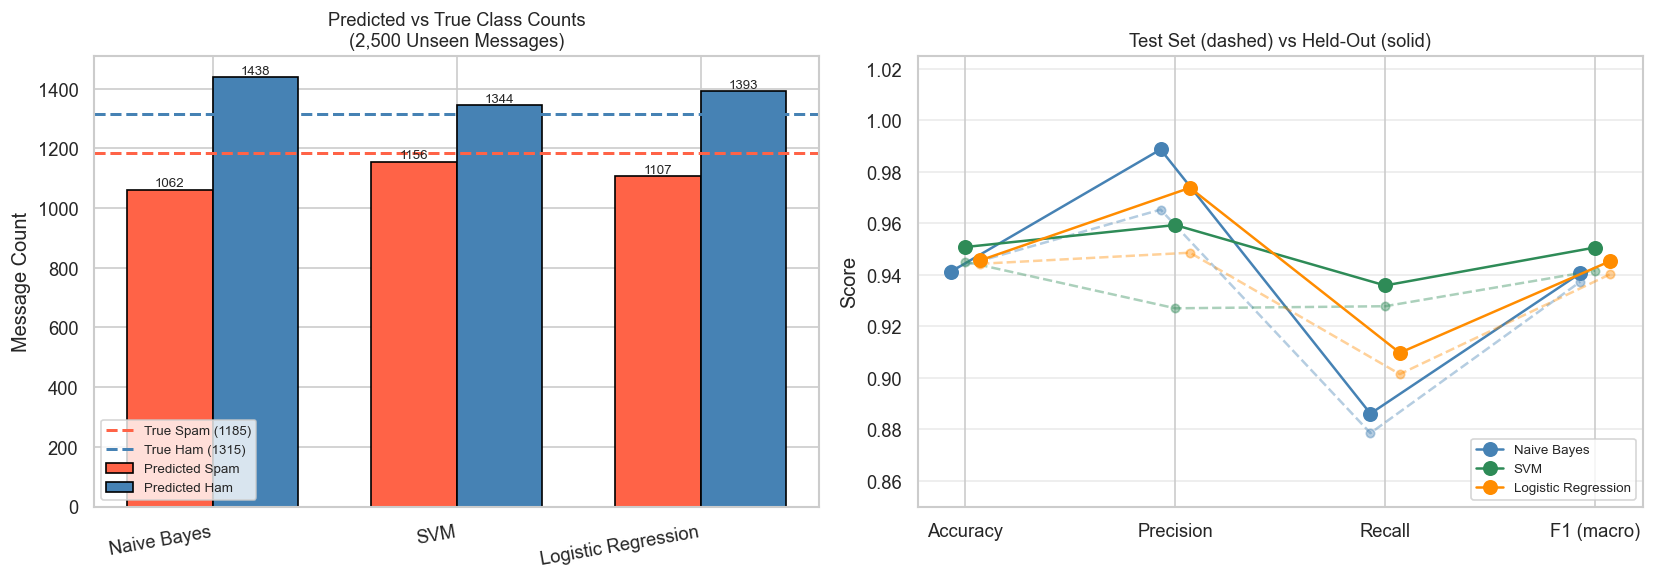

In [31]:
# --- Figure 14: Held-out prediction counts + test vs held-out generalisation ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

spam_cnts = {m: (holdout_preds[m] == 'spam').sum() for m in model_names_list}
ham_cnts  = {m: (holdout_preds[m] == 'ham').sum()  for m in model_names_list}
x     = np.arange(len(model_names_list))
width = 0.35

bars1 = axes[0].bar(x - width/2, list(spam_cnts.values()), width,
                    label='Predicted Spam', color='tomato', edgecolor='black')
bars2 = axes[0].bar(x + width/2, list(ham_cnts.values()),  width,
                    label='Predicted Ham',  color='steelblue', edgecolor='black')
true_spam = (y_holdout_true == 'spam').sum()
true_ham  = (y_holdout_true == 'ham').sum()
axes[0].axhline(true_spam, color='tomato',    ls='--', lw=1.8, label=f'True Spam ({true_spam})')
axes[0].axhline(true_ham,  color='steelblue', ls='--', lw=1.8, label=f'True Ham ({true_ham})')
for bar in list(bars1) + list(bars2):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 str(int(bar.get_height())), ha='center', fontsize=8)
axes[0].set_xticks(x); axes[0].set_xticklabels(model_names_list, rotation=10, ha='right')
axes[0].set_ylabel('Message Count')
axes[0].set_title('Predicted vs True Class Counts\n(2,500 Unseen Messages)', fontsize=11)
axes[0].legend(fontsize=8)

# Right: test set vs held-out per metric
metrics_ho = ['Accuracy', 'Precision', 'Recall', 'F1 (macro)']
x2 = np.arange(len(metrics_ho))
for i, (mname, color) in enumerate(zip(model_names_list, colors3)):
    test_v = [results_df.loc[mname, m] for m in metrics_ho]
    ho_v   = [holdout_df.loc[mname,  m] for m in metrics_ho]
    offset = (i - 1) * 0.07
    axes[1].plot(x2 + offset, test_v, 'o--', color=color, alpha=0.4, markersize=5)
    axes[1].plot(x2 + offset, ho_v,   'o-',  color=color, label=mname, markersize=8)
axes[1].set_xticks(x2); axes[1].set_xticklabels(metrics_ho)
axes[1].set_ylim(0.85, 1.025); axes[1].set_ylabel('Score')
axes[1].set_title('Test Set (dashed) vs Held-Out (solid)', fontsize=11)
axes[1].legend(fontsize=8, loc='lower right'); axes[1].grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('graphs/fig14_holdout_predictions.png', bbox_inches='tight')
plt.show()

### 10.2 Figure 15: Confusion Matrices on Held-Out Data


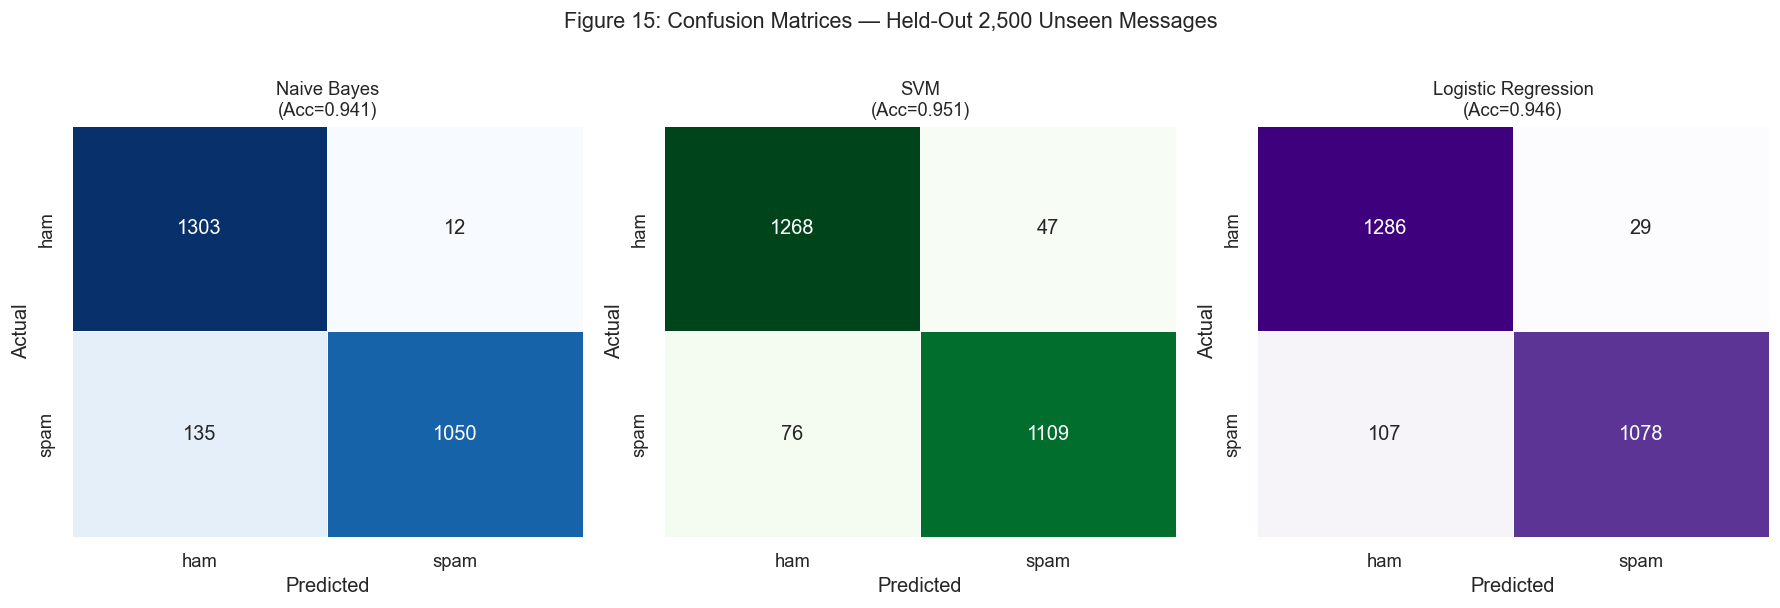

In [32]:
# --- Figure 16: Held-out Confusion Matrices (1×3) ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, mname, cmap in zip(axes, model_names_list, ['Blues', 'Greens', 'Purples']):
    y_pred = holdout_preds[mname]
    cm = confusion_matrix(y_holdout_true, y_pred, labels=['ham', 'spam'])
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['ham', 'spam'], yticklabels=['ham', 'spam'],
                linewidths=0.5, cbar=False)
    acc = accuracy_score(y_holdout_true, y_pred)
    ax.set_title(f'{mname}\n(Acc={acc:.3f})', fontsize=11)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.suptitle('Figure 15: Confusion Matrices — Held-Out 2,500 Unseen Messages', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('graphs/fig15_holdout_confusion.png', bbox_inches='tight')
plt.show()

### 10.3 Figure 16: Model Agreement & F1 Generalisation

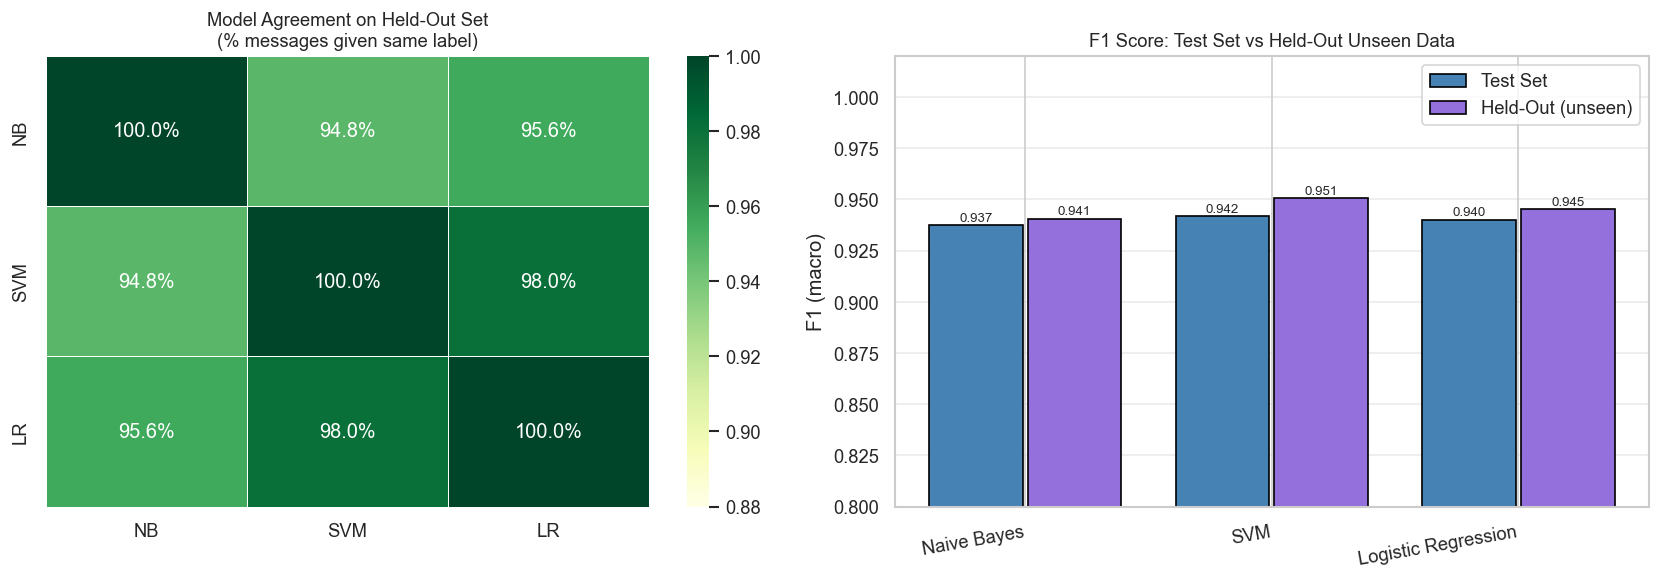

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Agreement heatmap
n_models = len(model_names_list)
agreement = np.zeros((n_models, n_models))
for i, m1 in enumerate(model_names_list):
    for j, m2 in enumerate(model_names_list):
        agreement[i, j] = (holdout_preds[m1] == holdout_preds[m2]).mean()
short = ['NB', 'SVM', 'LR']
sns.heatmap(agreement, annot=True, fmt='.1%', cmap='YlGn',
            xticklabels=short, yticklabels=short,
            vmin=0.88, vmax=1.0, ax=axes[0], linewidths=0.5)
axes[0].set_title('Model Agreement on Held-Out Set\n(% messages given same label)', fontsize=11)

# F1 generalisation bar chart
f1_test = [results_df.loc[m, 'F1 (macro)'] for m in model_names_list]
f1_ho   = [holdout_df.loc[m,  'F1 (macro)'] for m in model_names_list]
x3 = np.arange(len(model_names_list))
axes[1].bar(x3 - 0.2, f1_test, 0.38, label='Test Set',          color='steelblue',    edgecolor='black')
axes[1].bar(x3 + 0.2, f1_ho,   0.38, label='Held-Out (unseen)', color='mediumpurple', edgecolor='black')
for xi, (v1, v2) in enumerate(zip(f1_test, f1_ho)):
    axes[1].text(xi - 0.2, v1 + 0.002, f'{v1:.3f}', ha='center', fontsize=8)
    axes[1].text(xi + 0.2, v2 + 0.002, f'{v2:.3f}', ha='center', fontsize=8)
axes[1].set_xticks(x3); axes[1].set_xticklabels(model_names_list, rotation=10, ha='right')
axes[1].set_ylim(0.80, 1.02); axes[1].set_ylabel('F1 (macro)')
axes[1].set_title('F1 Score: Test Set vs Held-Out Unseen Data', fontsize=11)
axes[1].legend(); axes[1].grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('graphs/fig16_holdout_agreement.png', bbox_inches='tight')
plt.show()